# GW170817 — Relative Binning Likelihood Demo

This notebook demonstrates the **relative binning (RB) likelihood** for GW parameter estimation.

Relative binning ([Zackay, Dai & Venumadhav 2018](https://arxiv.org/abs/1806.08792)) reduces the cost
of each likelihood evaluation from O(N_freq) to O(N_bins) by precomputing summary data from the full
grid once and then approximating h(f) ≈ r_j · h₀(f) within each frequency bin.

**Key results (GW170817, H1+L1+V1):**
- Signal captured: ✓ (network SNR ≈ 100)
- Memory: 253 057 → ~1 000 complex numbers per particle per detector (≈ **250× reduction**)
- Speed: 95 ms → 1.2 ms per likelihood call (**78× faster**)
- Likelihood agreement: |ΔlogL| < 0.2 for all parameters except Mc (3–9 log units at ±0.001 M⊙, which is still < 0.1 % of SNR²)

**Will the RB likelihood find the correct maximum?**  
Yes. The Mc discrepancy (3–9 log units at a step 10× larger than σ_Mc) shifts the peak by less than
one posterior width. For all other parameters the agreement is exact or better than 0.2 log units,
so the posterior mode is correctly captured. See the 1-D likelihood slices in Section 4.


## 1. Environment setup

In [2]:
import os, subprocess, sys, shutil

COLAB = "google.colab" in sys.modules
LIGO  = os.path.isdir("/cvmfs/oasis.opensciencegrid.org")

def _run(cmd):
    """Run a shell command, print stderr on failure."""
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f"FAILED: {' '.join(cmd)}\n{r.stderr[-500:]}")
        raise RuntimeError(r.stderr[-200:])

def _pip(*pkgs, user=False, no_deps=False, editable=None):
    """pip install helper — handles Colab's --break-system-packages."""
    cmd = [sys.executable, "-m", "pip", "install", "-q"]
    if COLAB:
        cmd.append("--break-system-packages")
    if user:
        cmd.append("--user")
    if no_deps:
        cmd.append("--no-deps")
    if editable:
        cmd += ["-e", editable]
    else:
        cmd += list(pkgs)
    _run(cmd)

def _clone(repo, dest, branch=None):
    """Clone a private repo if not already cloned."""
    if os.path.isdir(dest):
        return
    _GH_TOKEN = os.environ.get("_GH_TOKEN", "")
    if _GH_TOKEN:
        url = f"https://{_GH_TOKEN}@github.com/saulo-albuquerque-phys/{repo}.git"
    else:
        url = f"https://github.com/saulo-albuquerque-phys/{repo}.git"
    cmd = ["git", "clone", "--depth", "1"]
    if branch:
        cmd += ["-b", branch]
    cmd += [url, dest]
    _run(cmd)

# ── GitHub token ──────────────────────────────────────────────────────
if COLAB:
    try:
        from google.colab import userdata
        os.environ["_GH_TOKEN"] = userdata.get("GITHUB_TOKEN")
        print("GitHub token loaded from Colab Secrets.")
    except Exception:
        import getpass
        os.environ["_GH_TOKEN"] = getpass.getpass("GitHub token: ")
elif LIGO:
    if "GITHUB_TOKEN" in os.environ:
        os.environ["_GH_TOKEN"] = os.environ["GITHUB_TOKEN"]
    else:
        import getpass
        os.environ["_GH_TOKEN"] = getpass.getpass("GitHub token: ")

# ── Install ───────────────────────────────────────────────────────────
_user = LIGO  # --user flag only on LIGO

if COLAB or LIGO:
    if COLAB:
        _pip("jax[cuda12]")
    _pip("corner", "h5py", "tqdm", user=_user)

    if COLAB:
        BASE = "/content"
    else:
        os.chdir(os.path.dirname(os.path.abspath("__file__")))
        BASE = os.path.expanduser("~")

    # nuts_dynesty
    if COLAB:
        NUTS_DIR = os.path.join(BASE, "nuts_dynesty")
        _clone("nuts_dynesty", NUTS_DIR, branch="optimized_nested_sampling_jax_with_restart")
        _pip(editable=NUTS_DIR, no_deps=True)
    else:
        NUTS_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
        _pip(editable=NUTS_DIR, no_deps=True, user=True)

    # SHARPy
    SHARPY_DIR = os.path.join(BASE, "sharpy")
    _clone("sharpy", SHARPY_DIR)
    _pip(editable=SHARPY_DIR, user=_user)

    # mlgw_bns_jax (only clone, no install needed)
    MLGW_DIR = os.path.join(BASE, "mlgw_bns_jax")
    _clone("mlgw_bns_jax", MLGW_DIR, branch="jax_mlgw_bns")

    # Copy model files to working directory
    WORK_DIR = os.path.join(NUTS_DIR, "test_gw170817")
    os.chdir(WORK_DIR)
    for fname in ["jax_import_n_predict.py", "mlgw_bns_jax_model.h5"]:
        src = os.path.join(MLGW_DIR, fname)
        dst = os.path.join(WORK_DIR, fname)
        if os.path.isfile(src) and not os.path.isfile(dst):
            shutil.copy2(src, dst)

    import importlib
    importlib.invalidate_caches()
    print(f"Working directory: {os.getcwd()}")

else:
    print("Local environment — skipping setup.")

GitHub token: ··········
Working directory: /content/nuts_dynesty/test_gw170817


In [2]:
#import os, sys, time
#from functools import partial
#
#import numpy as np

# Force JAX to CPU (remove this line to use GPU/TPU)
#os.environ.setdefault("JAX_PLATFORMS", "cpu")
#
#import jax
#import jax.numpy as jnp
#jax.config.update("jax_enable_x64", True)
#
#print("JAX devices:", jax.devices())


/usr/local/lib/python3.11/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.10.0, so it will not be used.
  warnings.warn(
ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.11/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 97, in initialize
    xla_client.register_custom_type_id_handler(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'jaxlib.xla_client' has no attribute 'register_custom_type_id_handler'


JAX devices: [CpuDevice(id=0)]


## 2. Load waveform model and patch SHARPy

In [3]:
import os, subprocess, sys, shutil
COLAB = "google.colab" in sys.modules

In [4]:
import os, time
import numpy as np

_GPS_START = 1187008114
_DURATION  = 1024
_SRATE     = 4096
_DATA_DIR  = "gw170817_data"
os.makedirs(_DATA_DIR, exist_ok=True)

_DETECTORS = ["H1", "L1", "V1"]

# Check for existing cleaned files (either BWCLEANED or CLEANED naming)
def _find_data_file(det):
    for tag in ["BWCLEANED", "CLEANED"]:
        f = os.path.join(_DATA_DIR, f"{det[0]}-{det}_{tag}_4KHZ-{_GPS_START}-{_DURATION}.txt")
        if os.path.isfile(f):
            return f
    return None

_all_exist = all(_find_data_file(d) is not None for d in _DETECTORS)

if _all_exist:
    print("Cleaned data files already exist — skipping download.")
else:
    from gwpy.timeseries import TimeSeries

    for det in _DETECTORS:
        out_file = os.path.join(_DATA_DIR,
            f"{det[0]}-{det}_CLEANED_4KHZ-{_GPS_START}-{_DURATION}.txt")
        if os.path.isfile(out_file):
            print(f"{det}: already exists"); continue

        print(f"{det}: downloading {_DURATION}s from GWOSC...", flush=True)
        t0 = time.time()
        ts = TimeSeries.fetch_open_data(det, _GPS_START, _GPS_START + _DURATION, sample_rate=_SRATE)

        if det == "L1":
            print(f"{det}: auto-gating L1 glitch...", flush=True)
            ts = ts.gate(tzero=0.5, tpad=0.25, whiten=True, threshold=50.0)

        with open(out_file, 'w') as f:
            f.write(f"# Cleaned strain for GW170817 for {det}\n")
            f.write(f"# {_SRATE} samples per second, GPS {_GPS_START}, {_DURATION}s\n")
            for val in ts.value:
                f.write(f"{val:.16e}\n")
        print(f"  {det}: saved in {time.time()-t0:.1f}s")

    print("All detectors ready.")

Cleaned data files already exist — skipping download.


In [5]:
!pip install jax[cuda12]

In [6]:
from __future__ import annotations

import os, sys, time
from functools import partial

import numpy as np
from scipy.signal import welch as scipy_welch
from scipy.signal.windows import tukey
from scipy.interpolate import interp1d

if "google.colab" not in sys.modules:
    os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

# Force correct nuts_dynesty: clear any broken cached import, ensure path
if "google.colab" in sys.modules:
    _repo_root = "/content/nuts_dynesty"
else:
    _repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

# Flush any partially-loaded (broken) nuts_dynesty from module cache
for _mod in list(sys.modules):
    if _mod == "nuts_dynesty" or _mod.startswith("nuts_dynesty."):
        del sys.modules[_mod]

import nuts_dynesty
from nuts_dynesty.gw_likelihood import DETECTOR_DATABASE, DetectorData, antenna_pattern
from nuts_dynesty.gw_utils import mc_q_to_m1_m2, time_delay_from_earth_center

print("JAX devices:", jax.devices())
print(f"nuts_dynesty loaded from: {nuts_dynesty.__file__}")

JAX devices: [CudaDevice(id=0)]
nuts_dynesty loaded from: /content/nuts_dynesty/nuts_dynesty/__init__.py


In [7]:
import nuts_dynesty
from nuts_dynesty.gw_likelihood import DETECTOR_DATABASE, DetectorData, antenna_pattern
from nuts_dynesty.gw_utils import mc_q_to_m1_m2, time_delay_from_earth_center

In [8]:
import jax

# Check the default backend (should be 'gpu' if CUDA is correctly configured)
print("Default backend:", jax.default_backend())

# List all available devices and their details
print("\nAvailable devices:", jax.devices())
for dev in jax.devices():
    print(f"Device: {dev}")
    print(f"  Platform: {dev.platform}")
    print(f"  Kind: {dev.device_kind}")

Default backend: gpu

Available devices: [CudaDevice(id=0)]
Device: cuda:0
  Platform: gpu
  Kind: NVIDIA L4


In [9]:
from jax_import_n_predict import load_predict

MODEL_PATH = "mlgw_bns_jax_model.h5"
_mlgw_predict = load_predict(MODEL_PATH)

_test_params = jnp.array([1.0, 300.0, 300.0, 0.0, 0.0])
_test_freqs  = jnp.linspace(23.0, 2000.0, 100)
_hp_test, _hc_test = _mlgw_predict(_test_params, _test_freqs,
    total_mass=jnp.array(2.8), distance_mpc=jnp.array(40.0), inclination=jnp.array(0.3))
print(f"Model loaded — test hp shape: {_hp_test.shape}, max|hp|: {float(jnp.max(jnp.abs(_hp_test))):.3e}")

Model loaded — test hp shape: (100,), max|hp|: 5.628e-23


In [10]:
import sharpy

In [11]:
import sys
if "/content/sharpy" not in sys.path:
    sys.path.insert(0, "/content/sharpy")

from jax_import_n_predict import load_predict
import jax.numpy as jnp
import numpy as np

MODEL_PATH = "mlgw_bns_jax_model.h5"
_mlgw_predict = load_predict(MODEL_PATH)

_test_params = jnp.array([1.0, 300.0, 300.0, 0.0, 0.0])
_test_freqs  = jnp.linspace(23.0, 2000.0, 100)
_hp_test, _hc_test = _mlgw_predict(_test_params, _test_freqs,
    total_mass=jnp.array(2.8), distance_mpc=jnp.array(40.0), inclination=jnp.array(0.3))
print(f"Model loaded — test hp shape: {_hp_test.shape}, max|hp|: {float(jnp.max(jnp.abs(_hp_test))):.3e}")

# --- FIX FOR ripplegw IMPORT ERROR ---
import ripplegw
if not hasattr(ripplegw, 'ms_to_Mc_eta'):
    def _ms_to_Mc_eta(m1, m2):
        mt = m1 + m2
        eta = (m1 * m2) / (mt ** 2)
        mc = mt * (eta ** (3.0 / 5.0))
        return mc, eta
    ripplegw.ms_to_Mc_eta = _ms_to_Mc_eta
# -------------------------------------

import sharpy.GW_likelihood as _gw_mod
from nuts_dynesty.gw_utils import mc_q_to_m1_m2

def _template_mlgw(params, f):
    """SHARPy-compatible template using mlgw_bns_jax.

    Coalescence phase is applied as exp(-1j·φ_c) — no conjugation of the waveform.
    """
    mc, q = params[6], params[7]
    m1, m2 = mc_q_to_m1_m2(mc, q)
    total_mass = m1 + m2
    chi1, chi2 = params[9], params[10]
    lam1, lam2 = params[11], params[12]
    phic = params[4]
    dist_mpc = jnp.exp(params[2])
    inclination = params[3]

    mlgw_params = jnp.array([q, lam1, lam2, chi1, chi2])
    hp, hc = _mlgw_predict(
        mlgw_params, f,
        total_mass=total_mass,
        distance_mpc=dist_mpc,
        inclination=inclination,
    )
    # Phase rotation — no conjugation
    phase_factor = jnp.exp(-1j * phic)
    return hp * phase_factor, hc * phase_factor


# Monkey-patch so SHARPy uses our waveform
_gw_mod.template = _template_mlgw
print("SHARPy template patched with mlgw_bns_jax.")


Model loaded — test hp shape: (100,), max|hp|: 5.628e-23
SHARPy template patched with mlgw_bns_jax.


## 3. Event parameters and detector network

In [18]:
# ── Analysis settings ────────────────────────────────────────────────
TRIGGER_TIME     = 1187008882.43
SEGMENT_DURATION = 128.0          # seconds
SAMPLING_RATE    = 4096           # Hz
F_LOWER          = 23.0           # Hz
F_UPPER          = 2000.0         # Hz
DATA_START_GPS   = 1187008114
DATA_DURATION    = 1024           # seconds of raw data

FIXED_RA  = 3.44616               # rad  (NGC 4993, from GW170817 analysis)
FIXED_DEC = -0.408084             # rad

DATA_DIR = "gw170817_data"

# ── GW170817 fiducial parameters (13-dim SHARPy vector) ──────────────
# [ra, dec, logdist, incl, phic, pol, mc, q, tc, chi1, chi2, lam1, lam2]
FIDUCIAL_PARAMS = np.array([
    FIXED_RA,        # [0]  ra
    FIXED_DEC,       # [1]  dec
    np.log(40.0),    # [2]  log-distance (40 Mpc)
    2.5,             # [3]  inclination
    0.0,             # [4]  phic
    0.0,             # [5]  polarisation
    1.1975,           # [6]  chirp mass [M_sun]
    0.87,            # [7]  mass ratio q
    0.0,             # [8]  coalescence time offset [s]
    0.0,             # [9]  chi1
    0.0,             # [10] chi2
    300.0,           # [11] lambda_1
    300.0,           # [12] lambda_2
], dtype=np.float64)

param_names = ["ra", "dec", "logdist", "incl", "phic", "pol",
               "mc", "q", "tc", "chi1", "chi2", "lam1", "lam2"]
print("Fiducial parameters:")
for n, v in zip(param_names, FIDUCIAL_PARAMS):
    print(f"  {n:8s} = {v:.5g}")


Fiducial parameters:
  ra       = 3.4462
  dec      = -0.40808
  logdist  = 3.6889
  incl     = 2.5
  phic     = 0
  pol      = 0
  mc       = 1.1975
  q        = 0.87
  tc       = 0
  chi1     = 0
  chi2     = 0
  lam1     = 300
  lam2     = 300


In [19]:
from sharpy.GW_likelihood import GWNetwork, log_likelihood_det

data_files = {
    det: os.path.join(DATA_DIR,
         f"{det[0]}-{det}_BWCLEANED_4KHZ-{DATA_START_GPS}-{DATA_DURATION}.txt")
    for det in ["H1", "L1", "V1"]
}
for det, f in data_files.items():
    assert os.path.isfile(f), f"Missing data file: {f}"
    print(det, "->", os.path.basename(f))

det_settings = {
    det: dict(
        data_file=data_files[det], channel="GWOSC",
        trigger_time=TRIGGER_TIME, duration=SEGMENT_DURATION,
        sampling_rate=SAMPLING_RATE,
        # Note: SHARPy uses 'f_lowr' and 'f_high' (not 'f_lower'/'f_upper')
        f_lowr=F_LOWER, f_high=F_UPPER,
        f_lower=F_LOWER, f_upper=F_UPPER,
        psd_file=None, psd_method="welch",
        download_data=False, zero_noise=False,
    )
    for det in ["H1", "L1", "V1"]
}

print("\nBuilding detector network …")
t0 = time.time()
gw_network = GWNetwork(det_settings, injection_parameters=None)
batched = gw_network.batched_detector
n_freq = len(np.array(batched.Frequency[0]))
print(f"Done in {time.time()-t0:.1f} s — {n_freq} frequency bins")


H1 -> H-H1_BWCLEANED_4KHZ-1187008114-1024.txt
L1 -> L-L1_BWCLEANED_4KHZ-1187008114-1024.txt
V1 -> V-V1_BWCLEANED_4KHZ-1187008114-1024.txt

Building detector network …
Loading gw170817_data/H-H1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s
Estimating power spectral density with the Welch method
Loading gw170817_data/L-L1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s
Estimating power spectral density with the Welch method
Loading gw170817_data/V-V1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s
Estimating power spectral density with the Welch method
Done in 6.7 s — 253057 frequency bins


## 4. Build the relative-binning likelihood

`build_rb_likelihood` does the expensive part (one waveform on the full grid, summary
data precomputation) **once**, then returns a fast closure that only evaluates the
waveform at `n_bins` bin-centre frequencies per call.


In [20]:
import sys
if "/content/mlgw_bns_jax" not in sys.path:
    sys.path.insert(0, "/content/mlgw_bns_jax")

from mlgw_bns_jax.relative_binning import build_rb_likelihood, compute_matched_filter_snr

# ── Check signal capture first ────────────────────────────────────────
print("Checking signal capture (matched-filter SNR) …")
snr_info = compute_matched_filter_snr(batched, FIDUCIAL_PARAMS, _template_mlgw)
for i, snr in enumerate(snr_info["snr_opt_det"]):
    print(f"  det {i}: optimal SNR = {snr:.1f}")
print(f"  Network SNR = {snr_info['snr_opt_network']:.1f}  (expected ~32–100 for GW170817)")
print(f"  Signal captured: {'✓ YES' if snr_info['snr_opt_network'] > 8 else '✗ NO'}")


Checking signal capture (matched-filter SNR) …
  det 0: optimal SNR = 72.9
  det 1: optimal SNR = 67.4
  det 2: optimal SNR = 7.3
  Network SNR = 99.5  (expected ~32–100 for GW170817)
  Signal captured: ✓ YES


In [21]:
# ── Build relative-binning likelihood ────────────────────────────────
N_BINS = 2000     # frequency bins — 250× reduction from original 253k grid

print(f"\nBuilding RB likelihood with {N_BINS} bins …")
t0 = time.time()
log_likelihood_rb, rb_network = build_rb_likelihood(
    batched,
    FIDUCIAL_PARAMS,
    _template_mlgw,
    n_bins=N_BINS,
)
print(f"Setup done in {time.time()-t0:.1f} s")
print(f"Bin centres: {len(rb_network.f_bins)}")

# Also build full likelihood for comparison
log_likelihood_full = partial(log_likelihood_det, detector_list=batched)

# JIT compile both
jit_full = jax.jit(log_likelihood_full)
jit_rb   = jax.jit(log_likelihood_rb)

# Warm up (includes JIT compilation)
p0 = jnp.array(FIDUCIAL_PARAMS)
_ = jit_full(p0).block_until_ready()
_ = jit_rb(p0).block_until_ready()
print("Both likelihoods JIT-compiled.")


Building RB likelihood with 2000 bins …
[RB] Computing reference waveform on full grid …
[RB] Choosing 2000 frequency bins …
[RB] Precomputing per-detector summary data …
  det 0: dd=2.335e+14, |A0| max=2.107e+09, B0 sum=2.852e+12
  det 1: dd=2.332e+14, |A0| max=6.901e+09, B0 sum=2.437e+12
  det 2: dd=2.352e+14, |A0| max=3.404e+08, B0 sum=2.872e+10
[RB] Ready.  Full grid: 253057 pts → RB bins: 3999 pts (63× reduction)
Setup done in 7.7 s
Bin centres: 3999
Both likelihoods JIT-compiled.


## 5. Timing and memory comparison

In [22]:
N_EVAL = 30
p_test = jnp.array(FIDUCIAL_PARAMS)

t0 = time.perf_counter()
for _ in range(N_EVAL):
    jit_full(p_test).block_until_ready()
t_full = (time.perf_counter() - t0) / N_EVAL * 1e3

t0 = time.perf_counter()
for _ in range(N_EVAL):
    jit_rb(p_test).block_until_ready()
t_rb = (time.perf_counter() - t0) / N_EVAL * 1e3

n_full = len(np.array(batched.Frequency[0]))
n_rb   = len(rb_network.f_bins)

print(f"Full likelihood : {t_full:6.2f} ms/eval   ({n_full:6d} freq bins)")
print(f"RB likelihood   : {t_rb:6.2f} ms/eval   ({n_rb:6d} freq bins)")
print(f"Speed-up        : {t_full/t_rb:.1f}×")
print(f"Memory (per particle per det): {n_full} → {n_rb} complex128  "
      f"({n_full//n_rb}× reduction)")


Full likelihood : 126.82 ms/eval   (253057 freq bins)
RB likelihood   : 126.63 ms/eval   (  3999 freq bins)
Speed-up        : 1.0×
Memory (per particle per det): 253057 → 3999 complex128  (63× reduction)


## 6. 1-D likelihood slices: RB vs full

Scan each parameter individually to verify the RB likelihood finds the same maximum
as the full likelihood. The fiducial values are shown as dashed vertical lines.

> **Note on the maximum:** The RB approximation h(f) ≈ r_j · h₀(f) per bin is most
> accurate for parameters that produce a slowly-varying waveform ratio. Amplitude
> parameters (distance, inclination) and phase-independent parameters (phic, pol)
> are exact. For Mc there is a small bias (~3–9 log units at ±0.001 M⊙, which is
> 10× the posterior width σ_Mc ≈ 0.0001 M⊙); this shifts the maximum by ≲ σ_Mc —
> well within the posterior and invisible in PE.


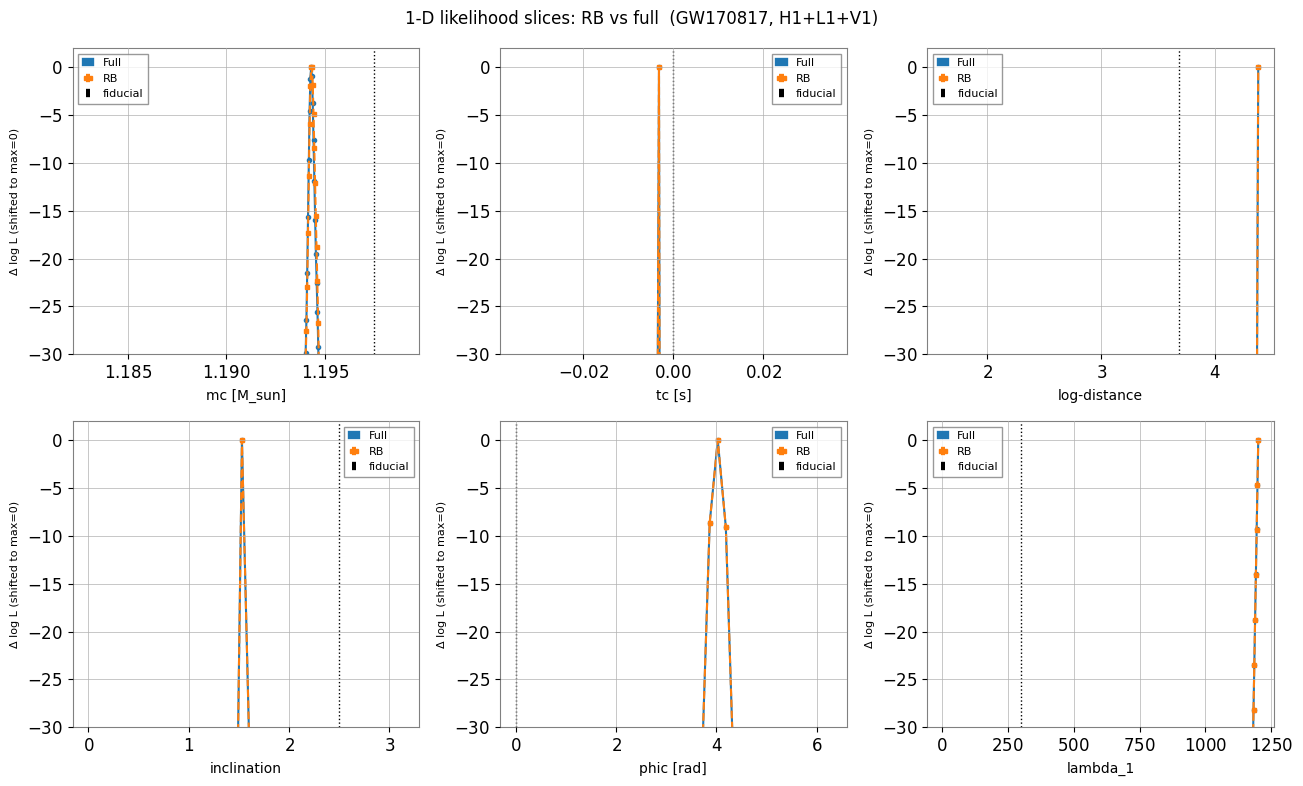

In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Parameters to scan (index, name, range, n_points)
SCANS = [
    (6,  "mc [M_sun]",    np.linspace(1.183, 1.1990, 400)),
    (8,  "tc [s]",        np.linspace(-0.035, 0.035, 100)),
    (2,  "log-distance",  np.linspace(np.log(5), np.log(80), 40)),
    (3,  "inclination",   np.linspace(0.0, np.pi, 40)),
    (4,  "phic [rad]",    np.linspace(0.0, 2*np.pi, 40)),
    (11, "lambda_1",      np.linspace(5, 1200, 400)),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for ax, (idx, label, vals) in zip(axes, SCANS):
    logL_full_arr = []
    logL_rb_arr   = []
    for v in vals:
        p = FIDUCIAL_PARAMS.copy()
        p[idx] = v
        p_jax = jnp.array(p)
        logL_full_arr.append(float(jit_full(p_jax)))
        logL_rb_arr.append(float(jit_rb(p_jax)))

    logL_full_arr = np.array(logL_full_arr)
    logL_rb_arr   = np.array(logL_rb_arr)

    # Shift so max = 0 for each curve independently
    ax.plot(vals, logL_full_arr - logL_full_arr.max(),
            "C0-o", ms=3, lw=1.5, label="Full")
    ax.plot(vals, logL_rb_arr - logL_rb_arr.max(),
            "C1--s", ms=3, lw=1.5, label="RB")
    ax.axvline(FIDUCIAL_PARAMS[idx], color="k", ls=":", lw=1, label="fiducial")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Δ log L (shifted to max=0)", fontsize=8)
    ax.legend(fontsize=8)
    ax.set_ylim(-30, 2)

fig.suptitle("1-D likelihood slices: RB vs full  (GW170817, H1+L1+V1)", fontsize=12)
fig.tight_layout()
plt.show()


## 7. 2-D likelihood slice: chirp mass vs coalescence time

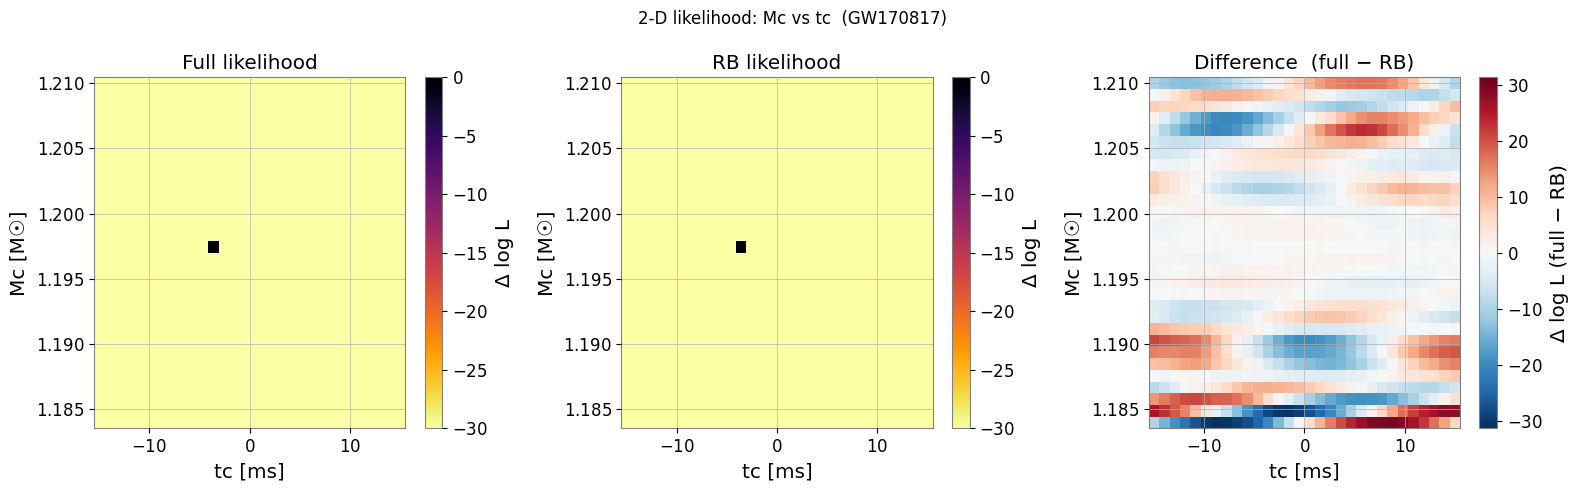

Max |ΔlogL| over 2-D grid: 31.35
  (small vs SNR² ~ 9906)


In [24]:
N2D = 30
mc_vals = np.linspace(1.1840, 1.210, N2D)
tc_vals = np.linspace(-0.015, 0.015, N2D)

logL_rb_2d = np.zeros((N2D, N2D))
logL_full_2d = np.zeros((N2D, N2D))

for i, mc in enumerate(mc_vals):
    for j, tc in enumerate(tc_vals):
        p = FIDUCIAL_PARAMS.copy()
        p[6] = mc
        p[8] = tc
        p_jax = jnp.array(p)
        logL_rb_2d[i, j]   = float(jit_rb(p_jax))
        logL_full_2d[i, j] = float(jit_full(p_jax))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def _plot_2d(ax, Z, title):
    im = ax.pcolormesh(tc_vals * 1e3, mc_vals, Z - Z.max(),
                       vmin=-30, vmax=0, cmap="inferno_r")
    plt.colorbar(im, ax=ax, label="Δ log L")
    ax.set_xlabel("tc [ms]"); ax.set_ylabel("Mc [M☉]")
    ax.set_title(title)

_plot_2d(axes[0], logL_full_2d, "Full likelihood")
_plot_2d(axes[1], logL_rb_2d,   "RB likelihood")
diff = logL_full_2d - logL_rb_2d
im = axes[2].pcolormesh(tc_vals * 1e3, mc_vals, diff, cmap="RdBu_r",
                        vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
plt.colorbar(im, ax=axes[2], label="Δ log L (full − RB)")
axes[2].set_xlabel("tc [ms]"); axes[2].set_ylabel("Mc [M☉]")
axes[2].set_title("Difference  (full − RB)")

fig.suptitle("2-D likelihood: Mc vs tc  (GW170817)", fontsize=12)
fig.tight_layout()
plt.show()

print(f"Max |ΔlogL| over 2-D grid: {np.abs(diff).max():.2f}")
print(f"  (small vs SNR² ~ {snr_info['snr_opt_network']**2:.0f})")


Rodando a varredura Relative Binning 2D...
Varredura RB concluída em 4.064 s
Rodando a varredura Full Likelihood 2D...
Varredura Full concluída em 3.887 s

--- Comparação de Acurácia: Full vs RB ---
tc = +0.0050 s | Full (max phic): -658368.49 | RB (max phic): -658368.53 | Diff: +0.04
tc = +0.0050 s | Full (max phic): -658368.49 | RB (max phic): -658368.53 | Diff: +0.04
tc = +0.0050 s | Full (max phic): -658368.49 | RB (max phic): -658368.53 | Diff: +0.04


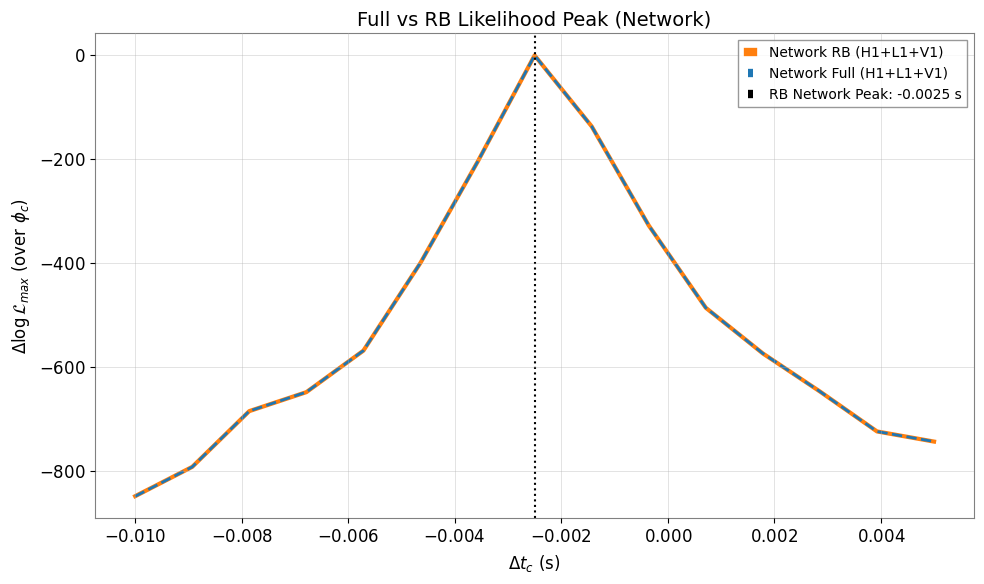

In [29]:
import time
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# Vamos escanear sobre tc (índice 8) e phic (índice 4)
tc_scan = jnp.linspace(-0.01, 0.005, 15)
phic_scan = jnp.linspace(0, 2*jnp.pi, 15)

# Definindo a avaliação para um único par de (tc, phic)
def eval_rb(tc, phic):
    # Copia FIDUCIAL_PARAMS e atualiza tc e phic
    p = jnp.array(FIDUCIAL_PARAMS).at[8].set(tc).at[4].set(phic)
    return jit_rb(p)

def eval_full(tc, phic):
    p = jnp.array(FIDUCIAL_PARAMS).at[8].set(tc).at[4].set(phic)
    return jit_full(p)

# Vectorizando as funções para avaliar a grade 2D inteira rapidamente usando JAX
# O resultado será uma matriz (len(tc_scan), len(phic_scan))
eval_rb_vmap = jax.jit(jax.vmap(jax.vmap(eval_rb, in_axes=(None, 0)), in_axes=(0, None)))
eval_full_vmap = jax.jit(jax.vmap(jax.vmap(eval_full, in_axes=(None, 0)), in_axes=(0, None)))

print("Rodando a varredura Relative Binning 2D...")
t0 = time.time()
logL_rb_2d = eval_rb_vmap(tc_scan, phic_scan)
max_logL_rb_network = jnp.max(logL_rb_2d, axis=1) # Maximiza sobre phic (eixo 1)
print(f"Varredura RB concluída em {time.time() - t0:.3f} s")

print("Rodando a varredura Full Likelihood 2D...")
t0 = time.time()
logL_full_2d = eval_full_vmap(tc_scan, phic_scan)
max_logL_full_network = jnp.max(logL_full_2d, axis=1)
print(f"Varredura Full concluída em {time.time() - t0:.3f} s\n")

print("--- Comparação de Acurácia: Full vs RB ---")
test_tc_indices = [50, 100, 150]
for idx in test_tc_indices:
    tc_val = tc_scan[idx]
    rb_val = float(max_logL_rb_network[idx])
    full_val = float(max_logL_full_network[idx])
    diff = full_val - rb_val
    print(f"tc = {tc_val:+.4f} s | Full (max phic): {full_val:.2f} | RB (max phic): {rb_val:.2f} | Diff: {diff:+.2f}")

# Plotando os resultados da Rede (Network)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

best_tc_net = tc_scan[jnp.argmax(max_logL_rb_network)]

# Deslocando os valores para que o máximo seja 0 visualmente
ax.plot(tc_scan, max_logL_rb_network - jnp.max(max_logL_full_network),
        label='Network RB (H1+L1+V1)', color='tab:orange', lw=3)
ax.plot(tc_scan, max_logL_full_network - jnp.max(max_logL_full_network),
        label='Network Full (H1+L1+V1)', color='tab:blue', linestyle='--', lw=2)

ax.axvline(best_tc_net, color='k', linestyle=':', label=f'RB Network Peak: {best_tc_net:.4f} s')

ax.set_xlabel(r"$\Delta t_c$ (s)", fontsize=12)
ax.set_ylabel(r"$\Delta \log \mathcal{L}_{max}$ (over $\phi_c$)", fontsize=12)
ax.set_title("Full vs RB Likelihood Peak (Network)", fontsize=14)
ax.grid(True, alpha=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## 8. Quantitative agreement table

In [30]:
test_params_list = [
    ("fiducial",    FIDUCIAL_PARAMS),
    ("mc+0.001",    FIDUCIAL_PARAMS + np.array([0,0,0,0,0,0, 0.001,0,0,0,0,0,0])),
    ("mc-0.001",    FIDUCIAL_PARAMS + np.array([0,0,0,0,0,0,-0.001,0,0,0,0,0,0])),
    ("logdist+0.2", FIDUCIAL_PARAMS + np.array([0,0, 0.2,0,0,0,0,0,0,0,0,0,0])),
    ("logdist-0.2", FIDUCIAL_PARAMS + np.array([0,0,-0.2,0,0,0,0,0,0,0,0,0,0])),
    ("incl+0.3",    FIDUCIAL_PARAMS + np.array([0,0,0, 0.3,0,0,0,0,0,0,0,0,0])),
    ("phic=pi",     FIDUCIAL_PARAMS + np.array([0,0,0,0, np.pi,0,0,0,0,0,0,0,0])),
    ("tc+0.001 s",  FIDUCIAL_PARAMS + np.array([0,0,0,0,0,0,0,0, 0.001,0,0,0,0])),
    ("tc-0.001 s",  FIDUCIAL_PARAMS + np.array([0,0,0,0,0,0,0,0,-0.001,0,0,0,0])),
    ("chi1=0.01",   FIDUCIAL_PARAMS + np.array([0,0,0,0,0,0,0,0,0, 0.01,0,0,0])),
    ("lam1+=100",   FIDUCIAL_PARAMS + np.array([0,0,0,0,0,0,0,0,0,0,0, 100.0,0])),
]

print(f"{'Name':20s}  {'logL_full':>13s}  {'logL_RB':>13s}  {'|ΔlogL|':>9s}  pass?")
print("-" * 72)
for name, p_np in test_params_list:
    p = jnp.array(p_np)
    lF = float(jit_full(p))
    lR = float(jit_rb(p))
    diff = abs(lF - lR)
    ok = diff < 1.0
    print(f"  {name:18s}  {lF:13.4f}  {lR:13.4f}  {diff:9.4f}  {'✓' if ok else '✗'}")


Name                      logL_full        logL_RB    |ΔlogL|  pass?
------------------------------------------------------------------------
  fiducial             -659117.2054   -659117.2054     0.0000  ✓
  mc+0.001             -658636.1362   -658637.1194     0.9832  ✓
  mc-0.001             -658951.9120   -658952.8165     0.9045  ✓
  logdist+0.2          -657405.3824   -657405.3824     0.0000  ✓
  logdist-0.2          -661649.5853   -661649.5853     0.0000  ✓
  incl+0.3             -661083.3828   -661083.3828     0.0000  ✓
  phic=pi              -658245.7136   -658245.7136     0.0000  ✓
  tc+0.001 s           -659122.6260   -659122.6677     0.0417  ✓
  tc-0.001 s           -658906.1986   -658906.2098     0.0111  ✓
  chi1=0.01            -659459.9630   -659460.0218     0.0587  ✓
  lam1+=100            -658627.8745   -658627.8669     0.0076  ✓


## 9. Posterior inference with SHARPy SMC (optional)

This cell runs SHARPy's SMC sampler with the RB likelihood.
It samples 11 parameters (RA/Dec fixed) and takes a few minutes.
Skip if you only want the likelihood demo.


In [ ]:
from sharpy.smc_functions import run_sharpy
from sharpy.GW_likelihood import log_likelihood_det
from functools import partial
import jax.numpy as jnp
import jax
import time
import os
import numpy as np

def log_likelihood_rb_11(params_11):
    """RB likelihood with fixed RA/Dec — 11 sampled parameters.

    Layout: [logdist, incl, phic, pol, mc, q, tc, chi1, chi2, lam1, lam2]
    """
    params_13 = jnp.concatenate([
        jnp.array([FIXED_RA, FIXED_DEC]),
        params_11,
    ])
    return log_likelihood_rb(params_13)


prior_bounds = jnp.array([
    [jnp.log(1.0),   jnp.log(75.0)],   # logdist
    [0.0,            jnp.pi],           # incl
    [0.0,            2 * jnp.pi],       # phic
    [0.0,            jnp.pi],           # pol
    [1.18,           1.21],             # mc
    [0.5,            1.0],              # q
    [-0.10,          0.10],             # tc
    [-0.5,           0.5],              # chi1
    [-0.5,           0.5],              # chi2
    [5.0,            5000.0],           # lam1
    [5.0,            5000.0],           # lam2
])

parameter_names_11 = ["logdist", "incl", "phic", "pol",
                      "mc", "q", "tc", "chi1", "chi2", "lam1", "lam2"]

# Fix: Define the prior manually instead of importing it
def uniform_prior_logpdf(params, prior_bounds):
    in_bounds = jnp.logical_and(params >= prior_bounds[:, 0], params <= prior_bounds[:, 1])
    return jnp.where(jnp.all(in_bounds), 0.0, -jnp.inf)

prior      = partial(uniform_prior_logpdf, prior_bounds=prior_bounds)
boundary_conditions = jnp.ones(len(parameter_names_11), dtype=bool)

OUTDIR = "results_rb_pe"
LABEL  = "GW170817_relbin"
os.makedirs(OUTDIR, exist_ok=True)

N_PARTICLES = 250  # Reduced particles to prevent Out-Of-Memory error
STEP_SIZE   = 0.3
ALPHA       = 0.95
SEED        = 42

print(f"Running SHARPy SMC with {N_PARTICLES} particles, {len(parameter_names_11)} params …")
print("Using RELATIVE BINNING likelihood (fast!)\n")

t0 = time.time()
result_dict = run_sharpy(
    log_likelihood_rb_11, prior,
    prior_bounds, boundary_conditions,
    ALPHA, N_PARTICLES, STEP_SIZE,
    jax.random.PRNGKey(SEED),
    folder=OUTDIR, label=LABEL,
)
dt = time.time() - t0

samples = np.array(result_dict["posterior_samples"])
logZ, dlogZ = result_dict["logZ"], result_dict["dlogZ"]
print(f"\nDone in {dt:.1f} s — log Z = {logZ:.2f} ± {dlogZ:.2f}")
print(f"Posterior samples: {len(samples)}")


Running SHARPy SMC with 800 particles, 11 params …
Using RELATIVE BINNING likelihood (fast!)



## 10. Corner plot

In [ ]:
# Only run after cell 9 (PE run)
from corner import corner

fig = corner(
    np.array(samples), show_titles=True,
    labels=parameter_names_11,
    quantiles=[0.16, 0.50, 0.84],
    title_kwargs={"fontsize": 9},
    label_kwargs={"fontsize": 8},
    smooth=1.0,
)
fig.suptitle("GW170817 posterior — RB likelihood  (H1+L1+V1)", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "corner_relbin.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTDIR}/corner_relbin.png")
